In [55]:
import pandas as pd
import os
import sys
from pathlib import Path

# =========================
# 1. Dateien laden
# =========================

project_root = Path.cwd()
if project_root.name == "Auswertung":
    project_root = project_root.parent

data_dir = project_root / "Daten" / "Daten final"
file_paths = sorted(data_dir.glob("PEI5mgmL_*.TXT"))

print(f"Python: {sys.version.split()[0]}")
print(f"pandas: {pd.__version__}")
print(f"Datenordner: {data_dir}")
print(f"Dateien: {len(file_paths)}")

print([path.name for path in file_paths])


Python: 3.14.5
pandas: 3.0.3
Datenordner: c:\Users\Max\Documents\bachelor thesis\code\Daten\Daten final
Dateien: 0
[]


In [56]:
from pathlib import Path
import pandas as pd

data_dir = Path(r"C:\Users\Max\Documents\bachelor thesis\data\Daten final")

file_paths = list(data_dir.glob("*.TXT")) + list(data_dir.glob("*.txt"))

if not data_dir.exists():
    raise FileNotFoundError(f"Ordner nicht gefunden: {data_dir}")

if not file_paths:
    raise FileNotFoundError(f"Keine .TXT-Dateien gefunden in: {data_dir}")

columns = [
    "Freq_Hz",
    "Time_s",
    "Eps_real",
    "Eps_imag",
    "Temp_K",
    "MTime_s",
    "Phi_deg",
    "Z_real_Ohm",
    "Z_imag_Ohm",
    "TanPhi"
]

dfs = []

for path in file_paths:

    df = pd.read_csv(
        path,
        sep=r"\s+",
        skiprows=4,
        names=columns,
        encoding="latin1",
        engine="python"
    )

    filename = path.stem
    parts = filename.split("_")

    if len(parts) >= 3:
        material = parts[0]
        temperature = parts[1]
        mode = parts[2]
    else:
        material = filename
        temperature = None
        mode = None

    first_freq = df["Freq_Hz"].iloc[0]
    df["Spectrum_ID"] = (df["Freq_Hz"] == first_freq).cumsum() - 1
    df["Spectrum_Number"] = df["Spectrum_ID"] + 1
    df["Point_Number"] = range(1, len(df) + 1)

    df["Material"] = material
    df["Temperature"] = temperature
    df["Mode"] = mode
    df["Source_File"] = path.name

    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

groups = df_all.groupby(
    ["Material", "Temperature", "Mode", "Spectrum_ID"],
    dropna=False
)

print(df_all)

          Freq_Hz  Time_s  Eps_real  Eps_imag  Temp_K  MTime_s  Phi_deg  \
0          100.00     0.0    1.8326  0.038560  323.11    11.10      NaN   
1          150.00     0.0    1.8229  0.038089  323.12    13.52      NaN   
2          225.00     0.0    1.8149  0.040726  323.12    18.82      NaN   
3          337.50     0.0    1.8052  0.042731  323.12    21.63      NaN   
4          506.25     0.0    1.7949  0.045478  323.13    24.07      NaN   
...           ...     ...       ...       ...     ...      ...      ...   
115811   65684.00  9911.7    5.2356  1.031700  363.15  9966.50  -78.852   
115812   98526.00  9911.7    4.8698  1.148900  363.15  9969.20  -76.725   
115813  147790.00  9911.7    4.4598  1.161800  363.15  9974.20  -75.399   
115814  221680.00  9911.7    4.0975  1.066900  363.15  9976.90  -75.406   
115815  332530.00  9911.7    3.7924  0.889170  363.15  9979.30  -76.805   

        Z_real_Ohm  Z_imag_Ohm  TanPhi  Spectrum_ID  Spectrum_Number  \
0              NaN         

In [57]:
series_counts = (
    df_all.groupby(["Material", "Temperature", "Mode"], dropna=False)
    .agg(
        Point_Count=("Point_Number", "count"),
        Spectrum_Count=("Spectrum_Number", "nunique"),
    )
    .reset_index()
    .sort_values(["Material", "Temperature", "Mode"])
)

print(series_counts.to_string(index=False))

Material Temperature Mode  Point_Count  Spectrum_Count
PEI2mgmL        50°C  Abs         8122             170
PEI2mgmL        50°C  Des        11846             247
PEI2mgmL        90°C  Abs         7698             161
PEI2mgmL        90°C  Des        11660             243
PEI5mgmL        50°C  Abs         5808             121
PEI5mgmL        50°C  Des         3350              70
PEI5mgmL        60°C  Abs         6622             138
PEI5mgmL        60°C  Des         9980             208
PEI5mgmL        70°C  Abs         5714             120
PEI5mgmL        70°C  Des        13308             278
PEI5mgmL        80°C  Abs         9096             190
PEI5mgmL        80°C  Des        10612             222
PEI5mgmL        90°C  Abs         6150             129
PEI5mgmL        90°C  Des         5850             122


Frequenzverlauf

Atmosphaerenwechsel bestimmen


Materialien: ['PEI2mgmL', 'PEI5mgmL']
Temperaturen: ['50°C', '60°C', '70°C', '80°C', '90°C']
Modi: ['Abs', 'Des']
Punktbereiche der geplotteten Spektren:
 Spectrum_Number  Point_Start  Point_End  Time_Start_s  Time_End_s
               5           97        120         340.4       414.9
               6          121        144         422.9       498.4
               7          145        168         506.5       576.1


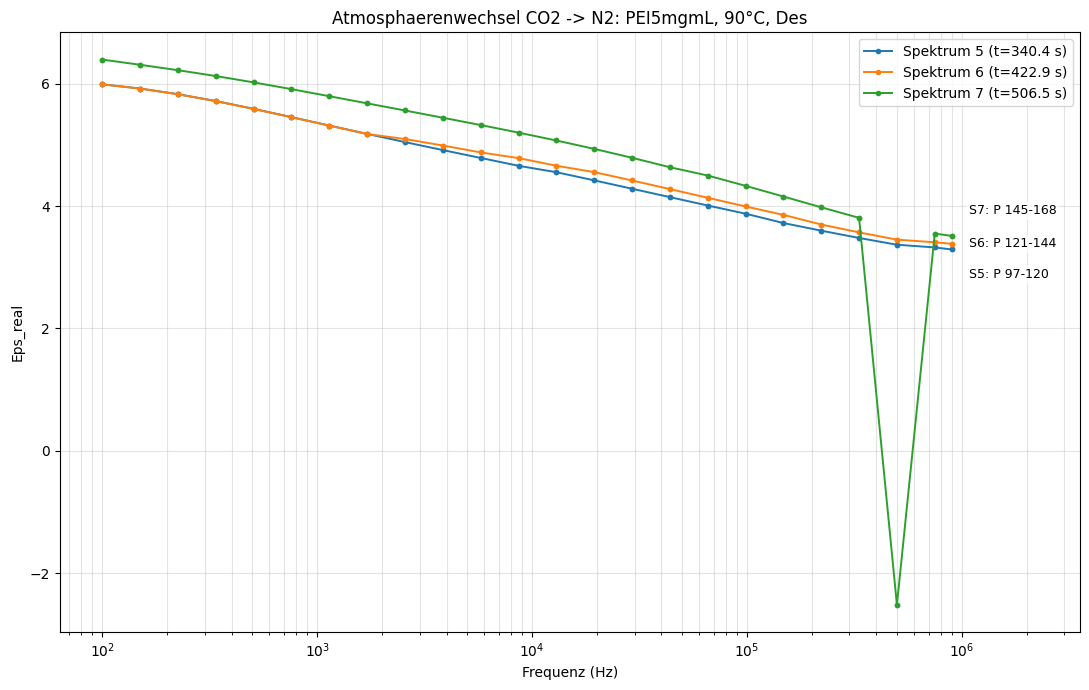

In [92]:
from pathlib import Path
import re
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Auswahl
# =========================

material = "PEI5mgmL"
temp = "90"           # Temperatur ohne Gradzeichen eintragen, z.B. "50", "70", "90"
mode = "Des"          # "Abs" = N2 -> CO2, "Des" = CO2 -> N2
y_col = "Eps_real"    # z.B. "Eps_real", "Eps_imag", "TanPhi"
spectrum_numbers = [5, 6, 7]

# Falls der Kernel neu gestartet wurde, werden die Daten hier automatisch geladen.
if "df_all" not in globals():
    notebook_dir = Path.cwd()
    project_root = notebook_dir.parent if notebook_dir.name.lower() == "code" else notebook_dir
    data_dir = project_root / "data" / "Daten final"

    columns = [
        "Freq_Hz",
        "Time_s",
        "Eps_real",
        "Eps_imag",
        "Temp_K",
        "MTime_s",
        "Phi_deg",
        "Z_real_Ohm",
        "Z_imag_Ohm",
        "TanPhi",
    ]

    file_paths = sorted(data_dir.glob("*.TXT")) + sorted(data_dir.glob("*.txt"))

    if not data_dir.exists():
        raise FileNotFoundError(f"Ordner nicht gefunden: {data_dir}")

    if not file_paths:
        raise FileNotFoundError(f"Keine .TXT-Dateien gefunden in: {data_dir}")

    dfs = []

    for path in file_paths:
        df = pd.read_csv(
            path,
            sep=r"\s+",
            skiprows=4,
            names=columns,
            encoding="latin1",
            engine="python",
        )

        parts = path.stem.split("_")
        material_from_file = parts[0] if len(parts) >= 1 else path.stem
        temperature_from_file = parts[1] if len(parts) >= 2 else None
        mode_from_file = parts[2] if len(parts) >= 3 else None

        first_freq = df["Freq_Hz"].iloc[0]
        df["Spectrum_ID"] = (df["Freq_Hz"] == first_freq).cumsum() - 1
        df["Spectrum_Number"] = df["Spectrum_ID"] + 1
        df["Point_Number"] = range(1, len(df) + 1)
        df["Material"] = material_from_file
        df["Temperature"] = temperature_from_file
        df["Mode"] = mode_from_file
        df["Source_File"] = path.name

        dfs.append(df)

    df_all = pd.concat(dfs, ignore_index=True)


def normalize_temperature(value):
    match = re.search(r"\d+", str(value))
    return match.group(0) if match else str(value)


# Zeigt die verfuegbaren Werte, falls du die Auswahl umstellen willst.
print("Materialien:", sorted(df_all["Material"].dropna().unique()))
print("Temperaturen:", sorted(df_all["Temperature"].dropna().unique()))
print("Modi:", sorted(df_all["Mode"].dropna().unique()))


def plot_atmosphere_switch(material, temp, mode, y_col="Eps_real", spectrum_numbers=(5, 6, 7)):
    temp_norm = normalize_temperature(temp)
    temperature_norm = df_all["Temperature"].map(normalize_temperature)

    df_sel = df_all[
        (df_all["Material"] == material) &
        (temperature_norm == temp_norm) &
        (df_all["Mode"] == mode)
    ].copy()

    if df_sel.empty:
        raise ValueError(
            f"Keine Daten gefunden fuer Material={material}, Temperature={temp}, Mode={mode}"
        )

    if y_col not in df_sel.columns:
        raise ValueError(f"Spalte nicht gefunden: {y_col}")

    spectrum_ids = [number - 1 for number in spectrum_numbers]
    available_ids = sorted(df_sel["Spectrum_ID"].unique())
    missing_numbers = [
        number
        for number, spec_id in zip(spectrum_numbers, spectrum_ids)
        if spec_id not in available_ids
    ]

    if missing_numbers:
        available_numbers = [spec_id + 1 for spec_id in available_ids]
        raise ValueError(
            f"Diese Spektren fehlen: {missing_numbers}. Verfuegbar sind: {available_numbers}"
        )

    temp_label = df_sel["Temperature"].iloc[0]
    direction = "N2 -> CO2" if mode == "Abs" else "CO2 -> N2" if mode == "Des" else "unbekannt"

    fig, ax = plt.subplots(figsize=(11, 7))
    spectrum_summary = []
    label_y_offsets = [-18, 0, 18, 36, -36]

    for plot_index, (number, spec_id) in enumerate(zip(spectrum_numbers, spectrum_ids)):
        spec = df_sel[df_sel["Spectrum_ID"] == spec_id].sort_values("Freq_Hz")
        time_start = spec["MTime_s"].iloc[0]
        time_end = spec["MTime_s"].iloc[-1]
        point_start = int(spec["Point_Number"].min())
        point_end = int(spec["Point_Number"].max())

        ax.plot(
            spec["Freq_Hz"],
            spec[y_col],
            marker="o",
            markersize=3,
            linewidth=1.4,
            label=f"Spektrum {number} (t={time_start:.1f} s)",
        )

        label_point = spec.iloc[-1]
        ax.annotate(
            f"S{number}: P {point_start}-{point_end}",
            (label_point["Freq_Hz"], label_point[y_col]),
            textcoords="offset points",
            xytext=(12, label_y_offsets[plot_index % len(label_y_offsets)]),
            ha="left",
            va="center",
            fontsize=9,
            bbox={"boxstyle": "round,pad=0.2", "facecolor": "white", "alpha": 0.75, "edgecolor": "none"},
        )

        spectrum_summary.append({
            "Spectrum_Number": number,
            "Point_Start": point_start,
            "Point_End": point_end,
            "Time_Start_s": round(float(time_start), 1),
            "Time_End_s": round(float(time_end), 1),
        })

    ax.set_xscale("log")
    xmin, xmax = ax.get_xlim()
    ax.set_xlim(xmin, xmax * 2.5)
    ax.set_xlabel("Frequenz (Hz)")
    ax.set_ylabel(y_col)
    ax.set_title(f"Atmosphaerenwechsel {direction}: {material}, {temp_label}, {mode}")
    ax.grid(True, which="both", alpha=0.35)
    ax.legend()
    #plt.xlim(10**5, 10**6)
    #plt.ylim(1.46, 1.52)
    plt.tight_layout()

    print("Punktbereiche der geplotteten Spektren:")
    print(pd.DataFrame(spectrum_summary).to_string(index=False))
    plt.show()


plot_atmosphere_switch(material, temp, mode, y_col, spectrum_numbers)


In [93]:
# Hier die manuell abgelesene Punktnummer des Atmosphaerenwechsels je Reihe eintragen.
# Format: (Material, Temperature, Mode): Point_Number

manual_switch_points = {
    ("PEI2mgmL", "50°C", "Abs"): 132,
    ("PEI2mgmL", "50°C", "Des"): 145,
    ("PEI2mgmL", "90°C", "Abs"): 151,
    ("PEI2mgmL", "90°C", "Des"): 152,
    ("PEI5mgmL", "50°C", "Abs"): 127,
    ("PEI5mgmL", "50°C", "Des"): 145,
    ("PEI5mgmL", "60°C", "Abs"): 127,
    ("PEI5mgmL", "60°C", "Des"): 145,
    ("PEI5mgmL", "70°C", "Abs"): 127,
    ("PEI5mgmL", "70°C", "Des"): 145,
    ("PEI5mgmL", "80°C", "Abs"): 128,
    ("PEI5mgmL", "80°C", "Des"): 128,
    ("PEI5mgmL", "90°C", "Abs"): 128,
    ("PEI5mgmL", "90°C", "Des"): 128,
}

series_overview = (
    df_all.groupby(["Material", "Temperature", "Mode"], dropna=False)
    .agg(
        First_Point=("Point_Number", "min"),
        Last_Point=("Point_Number", "max"),
        Spectrum_Count=("Spectrum_Number", "nunique"),
    )
    .reset_index()
    .sort_values(["Material", "Temperature", "Mode"])
)

atmosphere_switch_points = series_overview.copy()
atmosphere_switch_points["Switch_Point_Number"] = atmosphere_switch_points.apply(
    lambda row: manual_switch_points.get((row["Material"], row["Temperature"], row["Mode"])),
    axis=1,
)

invalid_switch_points = atmosphere_switch_points[
    atmosphere_switch_points["Switch_Point_Number"].notna()
    & ~atmosphere_switch_points["Switch_Point_Number"].between(
        atmosphere_switch_points["First_Point"],
        atmosphere_switch_points["Last_Point"],
    )
]

if not invalid_switch_points.empty:
    raise ValueError(
        "Mindestens eine eingetragene Switch_Point_Number liegt ausserhalb des Punktbereichs:\n"
        + invalid_switch_points.to_string(index=False)
    )

print(atmosphere_switch_points.to_string(index=False))


Material Temperature Mode  First_Point  Last_Point  Spectrum_Count  Switch_Point_Number
PEI2mgmL        50°C  Abs            1        4061             170                  132
PEI2mgmL        50°C  Des            1        5923             247                  145
PEI2mgmL        90°C  Abs            1        3849             161                  151
PEI2mgmL        90°C  Des            1        5830             243                  152
PEI5mgmL        50°C  Abs            1        2904             121                  127
PEI5mgmL        50°C  Des            1        1675              70                  145
PEI5mgmL        60°C  Abs            1        3311             138                  127
PEI5mgmL        60°C  Des            1        4990             208                  145
PEI5mgmL        70°C  Abs            1        2857             120                  127
PEI5mgmL        70°C  Des            1        6654             278                  145
PEI5mgmL        80°C  Abs       

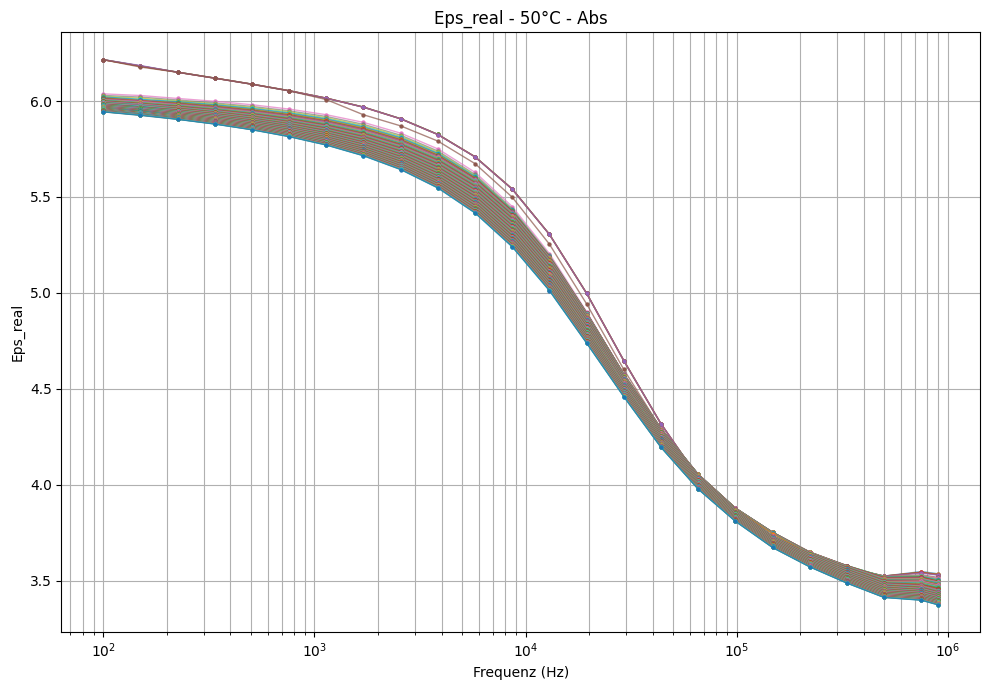

In [60]:
import matplotlib.pyplot as plt

# =========================
# Auswahl
# =========================

temp = "50°C"
material = "PEI5mgmL"
mode = "Abs"
y_col = "Eps_real"

df_sel = df_all[
    (df_all["Temperature"] == temp) &
    (df_all["Material"] == material) &
    (df_all["Mode"] == mode)
].copy()

if df_sel.empty:
    raise ValueError(f"Keine Daten gefunden für Temperature={temp} und Mode={mode}")

# =========================
# Sichere Gruppierung
# =========================

group_cols = []

for col in ["Source_File", "Material", "Temperature", "Mode", "Spectrum_ID"]:
    if col in df_sel.columns:
        group_cols.append(col)

# =========================
# Plot
# =========================

plt.figure(figsize=(10, 7))

for keys, spec in df_sel.groupby(group_cols, dropna=False):
    spec = spec.sort_values("Freq_Hz")

    plt.plot(
        spec["Freq_Hz"],
        spec[y_col],
        marker="o",
        markersize=2,
        linewidth=1,
        alpha=0.7
    )

plt.xscale("log")
plt.xlabel("Frequenz (Hz)")
plt.ylabel(y_col)
plt.title(f"{y_col} - {temp} - {mode}")
plt.grid(True, which="both")
plt.tight_layout()
plt.show()

Zeitverlauf

Absorption

$\epsilon'$

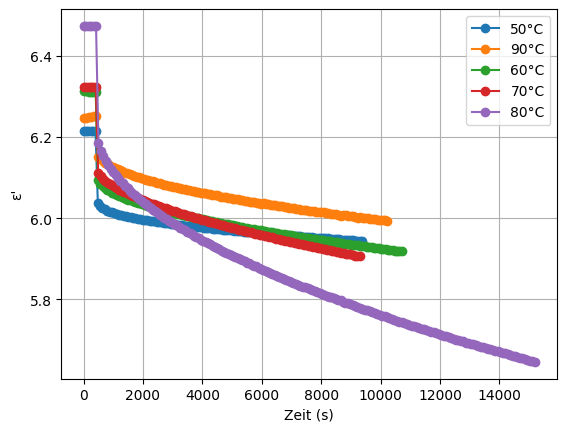

In [61]:
import pandas as pd
import matplotlib.pyplot as plt

f0 = 100
material = "PEI5mgmL"
mode = "Abs"
temps = df_all["Temperature"].unique()

plt.figure()

for temp in temps:

    df_sel = df_all[
        (df_all["Temperature"] == temp) &
        (df_all["Material"] == material) &
        (df_all["Mode"] == mode)
    ]

    if df_sel.empty:
        continue

    groups = df_sel.groupby("Spectrum_ID")

    time_series = []

    for spec_id, spec in groups:

        row = spec.loc[(spec["Freq_Hz"] - f0).abs().idxmin()]

        time_series.append([
            spec["MTime_s"].iloc[0],
            row["Eps_real"]
        ])

    eps_time_df = pd.DataFrame(time_series, columns=["Time_s", "Eps_real"])
    eps_time_df = eps_time_df.sort_values("Time_s")

    plt.plot(
        eps_time_df["Time_s"],
        eps_time_df["Eps_real"],
        marker="o",
        label=temp
    )

plt.xlabel("Zeit (s)")
plt.ylabel("ε'")
plt.grid(True)
plt.legend()
plt.show()

$\epsilon''$

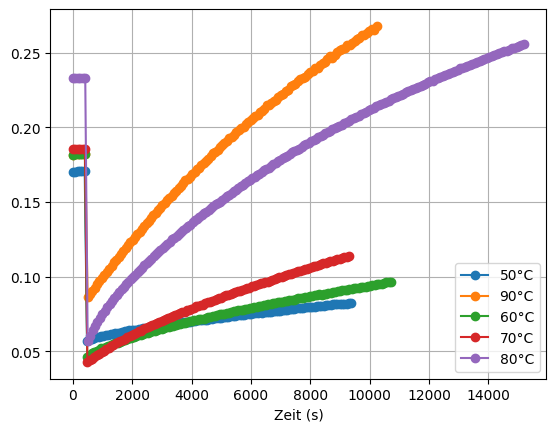

In [62]:
import pandas as pd
import matplotlib.pyplot as plt

f0 = 100
mode = "Abs"
material = "PEI5mgmL"
temps = df_all["Temperature"].unique()

plt.figure()

for temp in temps:

    df_sel = df_all[
        (df_all["Temperature"] == temp) &
        (df_all["Material"] == material) &
        (df_all["Mode"] == mode)
    ]

    if df_sel.empty:
        continue

    groups = df_sel.groupby("Spectrum_ID")

    time_series = []

    for spec_id, spec in groups:

        row = spec.loc[(spec["Freq_Hz"] - f0).abs().idxmin()]

        time_series.append([
            spec["MTime_s"].iloc[0],
            row["Eps_imag"]
        ])

    eps_time_df = pd.DataFrame(time_series, columns=["Time_s", "Eps_imag"])
    eps_time_df = eps_time_df.sort_values("Time_s")

    plt.plot(
        eps_time_df["Time_s"],
        eps_time_df["Eps_imag"],
        marker="o",
        label=temp
    )

plt.xlabel("Zeit (s)")
#plt.ylabel("ε'")
plt.grid(True)
plt.legend()
plt.show()

$\epsilon'$

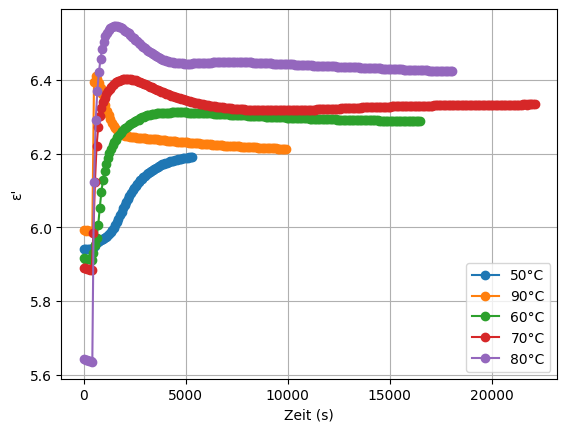

In [63]:
import pandas as pd
import matplotlib.pyplot as plt

f0 = 100
mode = "Des"
material = "PEI5mgmL"
temps = df_all["Temperature"].unique()

plt.figure()

for temp in temps:

    df_sel = df_all[
        (df_all["Temperature"] == temp) &
        (df_all["Material"] == material) &
        (df_all["Mode"] == mode)
    ]

    if df_sel.empty:
        continue

    groups = df_sel.groupby("Spectrum_ID")

    time_series = []

    for spec_id, spec in groups:

        row = spec.loc[(spec["Freq_Hz"] - f0).abs().idxmin()]

        time_series.append([
            spec["MTime_s"].iloc[0],
            row["Eps_real"]
        ])

    eps_time_df = pd.DataFrame(time_series, columns=["Time_s", "Eps_real"])
    eps_time_df = eps_time_df.sort_values("Time_s")

    plt.plot(
        eps_time_df["Time_s"],
        eps_time_df["Eps_real"],
        marker="o",
        label=temp
    )

plt.xlabel("Zeit (s)")
plt.ylabel("ε'")
plt.grid(True)
plt.legend()
plt.show()

$\epsilon''$

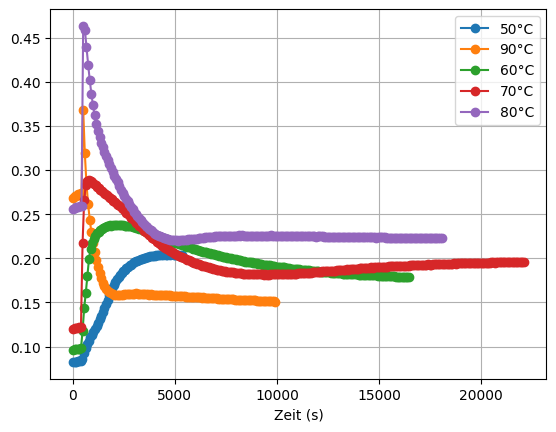

In [64]:
import pandas as pd
import matplotlib.pyplot as plt

f0 = 100
mode = "Des"
material = "PEI5mgmL"
temps = df_all["Temperature"].unique()

plt.figure()

for temp in temps:

    df_sel = df_all[
        (df_all["Temperature"] == temp) &
        (df_all["Material"] == material) &
        (df_all["Mode"] == mode)
    ]

    if df_sel.empty:
        continue

    groups = df_sel.groupby("Spectrum_ID")

    time_series = []

    for spec_id, spec in groups:

        row = spec.loc[(spec["Freq_Hz"] - f0).abs().idxmin()]

        time_series.append([
            spec["MTime_s"].iloc[0],
            row["Eps_imag"]
        ])

    eps_time_df = pd.DataFrame(time_series, columns=["Time_s", "Eps_imag"])
    eps_time_df = eps_time_df.sort_values("Time_s")

    plt.plot(
        eps_time_df["Time_s"],
        eps_time_df["Eps_imag"],
        marker="o",
        label=temp
    )

plt.xlabel("Zeit (s)")
#plt.ylabel("ε'")
plt.grid(True)
plt.legend()
plt.show()

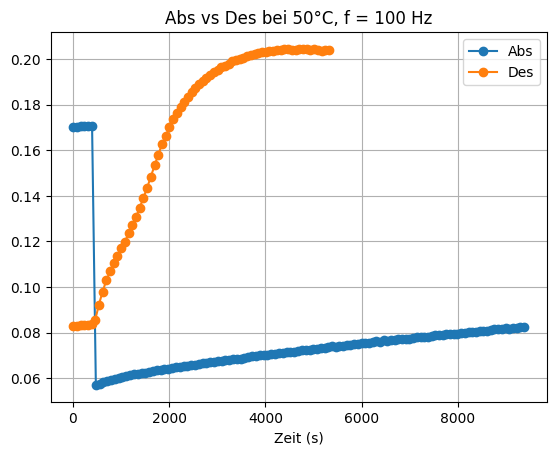

In [65]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Parameter
# =========================

f0 = 100
material = "PEI5mgmL"
temp = "50°C"

modes = ["Abs", "Des"]

plt.figure()

# =========================
# Loop über Abs / Des
# =========================

for mode in modes:

    df_sel = df_all[
        (df_all["Temperature"] == temp) &
        (df_all["Material"] == material) &
        (df_all["Mode"] == mode)
    ]

    if df_sel.empty:
        continue

    groups = df_sel.groupby("Spectrum_ID")

    time_series = []

    for spec_id, spec in groups:

        row = spec.loc[(spec["Freq_Hz"] - f0).abs().idxmin()]

        time_series.append([
            spec["MTime_s"].iloc[0],
            row["Eps_imag"]
        ])

    eps_time_df = pd.DataFrame(time_series, columns=["Time_s", "Eps_imag"])
    eps_time_df = eps_time_df.sort_values("Time_s")

    plt.plot(
        eps_time_df["Time_s"],
        eps_time_df["Eps_imag"],
        marker="o",
        label=mode
    )

# =========================
# Plot Styling
# =========================

plt.xlabel("Zeit (s)")
#plt.ylabel("ε'")
plt.title(f"Abs vs Des bei {temp}, f = {f0} Hz")
plt.grid(True)
plt.legend()

plt.show()